# Fine-tuned LaBraM — evaluation & inference notebook

Apply a **trained fine-tune model** to the validation / test split of an EEG
dataset and analyse its predictions offline. Every heavy piece of logic lives in
the reusable `labram.eval` package (and is unit-tested in
`tests/test_eval_toolkit.py`); this notebook only orchestrates and visualizes.

**What it covers**

0. **Load** the model, run config and `data_split.json` — from a local run
   directory, a **ClearML experiment**, or a self-contained **synthetic demo**.
0. **Verify** evaluation metrics computed **per window** *and* **per whole EEG
   case** under several aggregation methods.
1. **Compare** aggregation methods — `mean`, `median`, entropy-(confidence-)
   weighted.
2. **Visualize** the metric curves — ROC, PR, F1/accuracy vs threshold, and
   **confusion matrices per threshold**.
3. **Entropy vs accuracy** — is the model more accurate when it is more confident?
4. **Effectiveness of the entropy label** — selective prediction: does rejecting
   uncertain windows raise accuracy?
5. A **good** and a **poor** case — visualize the raw EEG and the per-window
   prediction trace.

> Set `USE_SYNTHETIC = False` and fill in `LOCAL_DIR` **or** the `CLEARML_*`
> fields to evaluate a real experiment.

## Configuration

Choose the source of the trained model and the split to evaluate.

In [1]:
# --- source selection -------------------------------------------------------
USE_SYNTHETIC = True          # self-contained demo; no real data/checkpoint needed

# (a) local run directory containing checkpoint-*.pth / run_config.* / data_split.json
LOCAL_DIR = ""                # e.g. "./checkpoints/finetune_tuab_base"

# (b) ClearML experiment (requires the `clearml` package + credentials)
CLEARML_TASK_ID = ""          # e.g. "1234abcd..."; or use project + task name below
CLEARML_PROJECT = "LaBraM"
CLEARML_TASK_NAME = ""

# (c) fallback architecture when no run config is available
MODEL_NAME = "labram_base_patch200_200"

# --- data / evaluation options ---------------------------------------------
DATASET = "TUAB"              # TUAB (binary) or TUEV (6-class)
DATA_PATH = ""                # dataset root (real mode)
SPLIT = "test"                # which split to evaluate: "val" or "test"
AGG_CASE_BY = "recording"     # aggregate windows per "recording" or per "subject"
BATCH_SIZE = 64
DEVICE = "cpu"                # "cpu" / "cuda" / "mps"
THRESHOLD = 0.5               # binary decision threshold

import warnings; warnings.filterwarnings("ignore")

In [2]:
%matplotlib inline
import os, sys
# Make the repo importable when the notebook is opened from notebooks/.
if not any(os.path.isdir(os.path.join(p, "labram")) for p in sys.path):
    sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import torch

import labram.models.registry  # noqa: F401  (registers timm factories)
from labram import eval as leval
from labram.eval import plots as eplots
from labram.utils import threshold_sweep

device = torch.device(DEVICE)
print("labram.eval loaded; device =", device)

labram.eval loaded; device = cpu


## 0 · Load the model, config and data split

`labram.eval.loading` resolves the three artifacts an evaluation needs — the
**trained checkpoint**, the **run config** (for the exact architecture) and the
**`data_split.json`** record — from whichever source is configured. The
synthetic branch fabricates a tiny TUAB-like dataset and a lightweight surrogate
scorer so the whole notebook runs end-to-end offline.

In [3]:
def build_synthetic():
    """Tiny TUAB-like dataset + a surrogate scorer, for an offline demo.

    Each recording gets a class-dependent signal offset; per-window Gaussian
    noise makes individual windows ambiguous, so window aggregation and the
    entropy analyses have something to work with.
    """
    import tempfile, pickle, os
    from labram.data.tuh_datasets import TUABLoader

    rng = np.random.RandomState(0)
    root = tempfile.mkdtemp(prefix="synthetic_tuab_")
    files = []
    n_rec, n_win, n_ch, T = 24, 8, 16, 2000
    for r in range(n_rec):
        label = int(r % 2)
        offset = 0.6 if label == 1 else -0.6
        subj = f"{r:04d}"
        for w in range(n_win):
            x = rng.randn(n_ch, T).astype("f4") * 0.5 + offset + rng.randn() * 0.7
            name = f"{subj}_s1_t0_{w}.pkl"
            files.append(name)
            with open(os.path.join(root, name), "wb") as f:
                pickle.dump({"X": (x * 100).astype("f4"), "y": label}, f)
    ds = TUABLoader(root, files)

    class SurrogateModel(torch.nn.Module):
        """logit proportional to the (scaled) per-window signal mean."""
        def forward(self, x, channel_indices=None, classify_only=True):
            b = x.shape[0]
            return (x.reshape(b, -1).mean(dim=1, keepdim=True) * 6.0)

    return SurrogateModel().eval(), ds, ["synthetic"], 1, True, None, None


if USE_SYNTHETIC:
    model, dataset, ch_names, nb_classes, is_binary, config, split = build_synthetic()
    ch_names_for_infer = None                     # surrogate ignores channels
    print("Synthetic demo:", len(dataset), "windows")
else:
    from labram.data import get_dataset_bundle
    # Resolve artifacts from a local dir or ClearML.
    if LOCAL_DIR:
        assets = leval.find_experiment_assets(LOCAL_DIR)
    else:
        assets = leval.load_clearml_assets(
            task_id=CLEARML_TASK_ID or None,
            project_name=CLEARML_PROJECT, task_name=CLEARML_TASK_NAME or None)
    print("Assets:", assets)

    bundle = get_dataset_bundle(DATASET, DATA_PATH)
    nb_classes, is_binary = bundle.nb_classes, bundle.nb_classes == 1
    ch_names = bundle.ch_names
    dataset = {"val": bundle.val, "test": bundle.test}[SPLIT]

    model, config, split = leval.load_model_from_assets(
        assets, device=device, model_name=MODEL_NAME, nb_classes=nb_classes)
    ch_names_for_infer = ch_names

model.to(device)
if split is not None:
    print("Data split:", {k: v.get("n_windows") for k, v in split.items()
                          if isinstance(v, dict) and "n_windows" in v})

Synthetic demo: 192 windows


### Run inference over the split

`build_case_loader` turns the dataset into a **sequential** loader that emits a
per-window **case id** (recording/subject), and returns the window file names in
order. `collect_predictions` then gathers the raw per-window probabilities,
logits, targets, case ids and file names into a `PredictionResult`.

In [4]:
loader, files = leval.build_case_loader(
    dataset, batch_size=BATCH_SIZE, agg_case_by=AGG_CASE_BY)

result = leval.collect_predictions(
    model, loader, device, is_binary=is_binary, nb_classes=nb_classes,
    ch_names=ch_names_for_infer, files=files)

n_cases = len(set(result.groups)) if result.groups is not None else len(result)
print(f"{len(result)} windows across {n_cases} cases")
print("class balance (windows):", np.bincount(result.targets))

192 windows across 24 cases
class balance (windows): [96 96]


## 0b · Metrics per window vs per whole EEG case

The same predictions are scored two ways: **window-level** (every 10 s window is
an independent example) and **case-level** (windows pooled into one prediction
per recording/subject). This confirms the aggregation path used during training
(`evaluation.agg_windows`) and quantifies how much pooling helps.

In [5]:
from labram.eval import comparison_table
import pandas as pd

reports = leval.compare_aggregations(
    result, modes=leval.DEFAULT_AGG_MODES, include_window=True, threshold=THRESHOLD)
table = pd.DataFrame(comparison_table(reports)).set_index("method")
print("Window-level = 'window'; case-level = mean/median/entropy\n")
table.round(4)

Window-level = 'window'; case-level = mean/median/entropy



,accuracy,balanced_accuracy,f1,roc_auc,pr_auc,sensitivity,specificity
method,,,,,,,
window,0.8073,0.8073,0.8063,0.8811,0.8784,0.8021,0.8125
mean,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
median,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
entropy,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


## 1 · Compare aggregation methods

`mean` (probabilistic average), `median` (robust to outlier windows) and
`entropy` (confidence-weighted — uncertain windows are down-weighted). Bars
compare headline metrics; the ROC/PR overlay compares ranking quality.

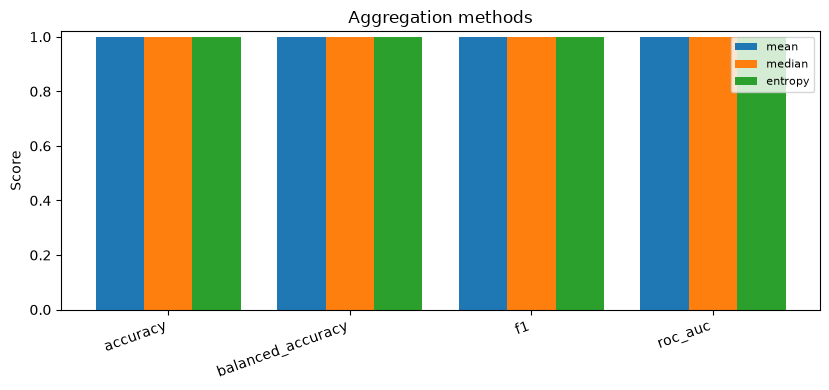

In [6]:
case_reports = {k: v for k, v in reports.items() if k != "window"}
fig = eplots.aggregation_comparison_figure(
    case_reports, metrics=("accuracy", "balanced_accuracy", "f1", "roc_auc"))
fig

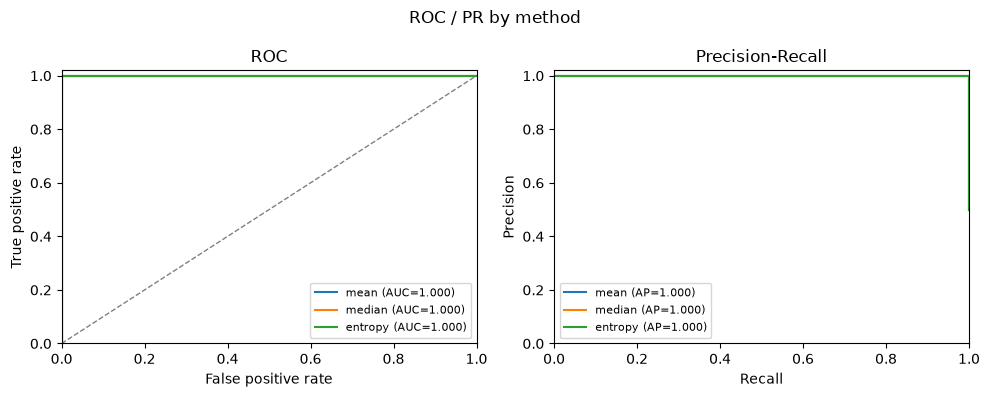

In [7]:
# ROC / PR overlay per method (binary only).
if is_binary:
    fig = eplots.roc_pr_overlay_figure(case_reports)
else:
    fig = None
    print("ROC/PR overlay is binary-only; skipping for multiclass.")
fig

## 2 · Metric curves & confusion matrices per threshold

For the chosen aggregation, sweep the decision threshold and plot
accuracy / F1 / precision / recall / specificity, then show confusion matrices
at a few operating points.

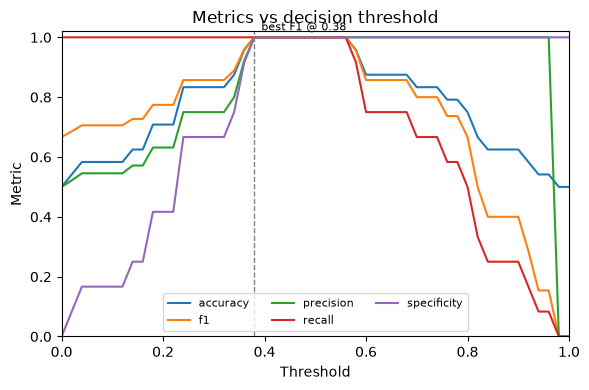

In [8]:
AGG_FOR_CURVES = "mean"   # which aggregation to threshold-analyse

if is_binary:
    scores, targets = leval.aggregate_result(result, AGG_FOR_CURVES, threshold=THRESHOLD)
    scores = scores.ravel(); targets = targets.ravel()
    sweep = threshold_sweep(scores, targets)
    fig = eplots.metric_vs_threshold_figure(sweep)
else:
    fig = None
    print("Threshold sweep is binary-only.")
fig

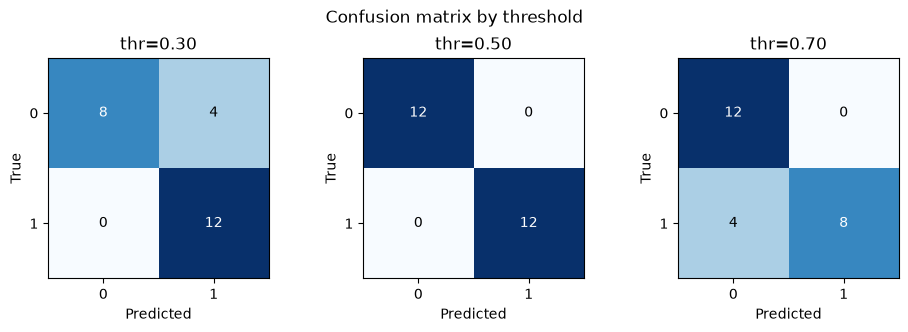

In [9]:
if is_binary:
    fig = eplots.confusion_matrices_grid(scores, targets, thresholds=(0.3, 0.5, 0.7))
else:
    # Multiclass: single confusion matrix from the report.
    rep = leval.report_for_mode(result, AGG_FOR_CURVES)
    fig = eplots.confusion_matrix_figure(rep.matrix, labels=rep.labels)
fig

## 3 · Entropy vs accuracy

Bin the **per-window** predictions by their normalized entropy and measure
accuracy per bin. A calibrated model is more accurate on low-entropy (confident)
windows — the accuracy curve should fall as entropy rises.

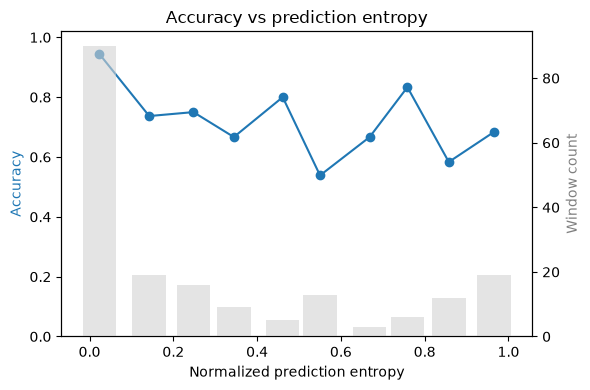

In [10]:
ea = leval.entropy_accuracy_curve(result, n_bins=10, threshold=THRESHOLD)
fig = eplots.entropy_accuracy_figure(ea)
fig

## 4 · Effectiveness of the entropy label (selective prediction)

Treat entropy as a **confidence / abstention signal**: sort windows from most to
least confident and, at each coverage level, keep only that most-confident
fraction. If entropy is informative, accuracy rises as coverage drops — so it can
be used to flag unreliable windows (e.g. route them for review or exclude them
from case aggregation).

Accuracy @100% coverage: 0.807  |  @50% coverage: 0.906


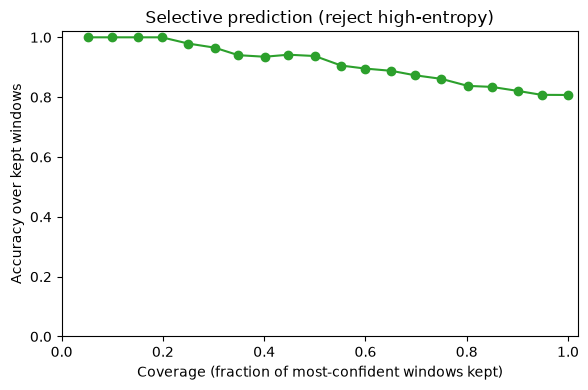

In [11]:
sel = leval.selective_accuracy(result, threshold=THRESHOLD, n_points=20)
fig = eplots.selective_accuracy_figure(sel)
print(f"Accuracy @100% coverage: {sel.accuracy[-1]:.3f}  |  "
      f"@50% coverage: {sel.accuracy[len(sel.accuracy)//2]:.3f}")
fig

## 5 · A good case and a poor case

Rank cases by how confidently-correct their aggregated prediction is, then take
the **best** and **worst**. For each we plot the raw EEG of one window and the
per-window prediction trace across the whole case (bars green when the window is
correct, red when wrong; entropy overlaid).

In [12]:
import os, pickle

def load_window_signal(dataset, filename):
    """Reload the raw (channels, time) signal for a window file."""
    base = dataset.dataset if isinstance(dataset, torch.utils.data.Subset) else dataset
    with open(os.path.join(base.root, filename), "rb") as fh:
        return np.asarray(pickle.load(fh)[base._signal_key], dtype=float)

ranked = leval.rank_cases(result, mode="mean", threshold=THRESHOLD)
best_case = ranked[0][0]
worst_case = ranked[-1][0]
print("Best  case:", ranked[0])
print("Worst case:", ranked[-1])

Best  case: ('0022_s1_t0', 0.014008478814503178, 0, 0.4859915211854968)
Worst case: ('0013_s1_t0', 0.566664844751358, 1, 0.06666484475135803)


[GOOD] case=0022_s1_t0  target=0  windows=8


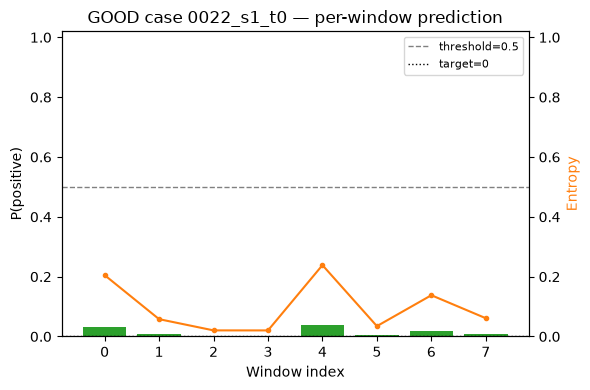

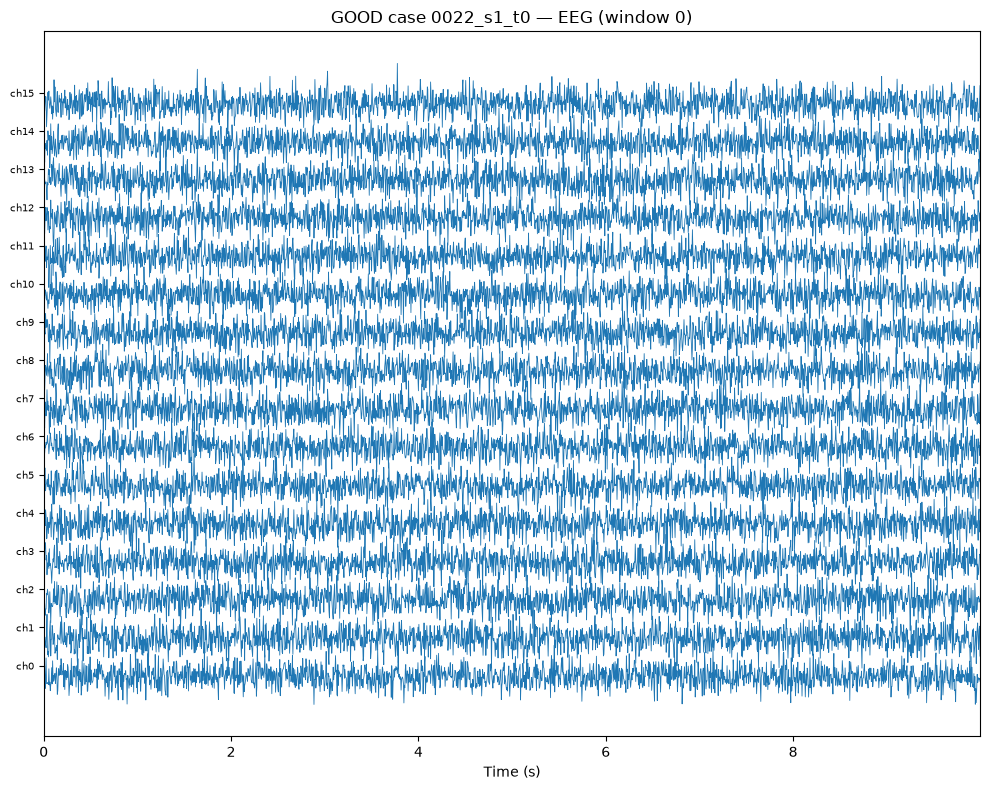

[POOR] case=0013_s1_t0  target=1  windows=8


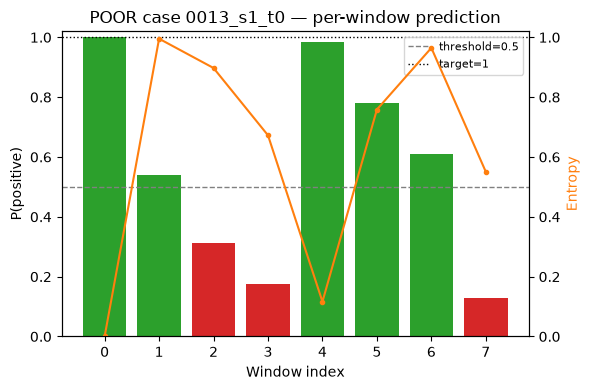

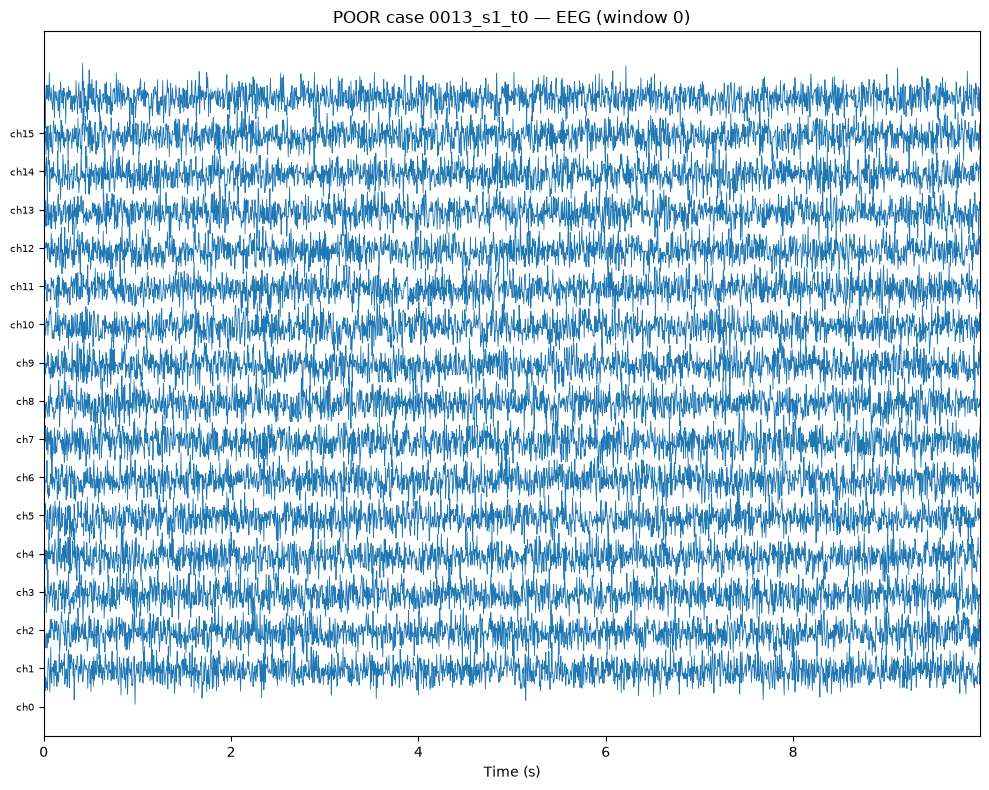

In [13]:
def show_case(case_id, tag):
    cw = leval.case_window_predictions(result, case_id)
    target = int(cw["target"][0])
    print(f"[{tag}] case={case_id}  target={target}  windows={len(cw['probs'])}")
    # Per-window prediction trace.
    probs = cw["probs"] if is_binary else cw["probs"].max(axis=1)
    fig1 = eplots.window_prediction_figure(
        probs, target, threshold=THRESHOLD, entropy=cw["entropy"],
        title=f"{tag} case {case_id} — per-window prediction")
    display(fig1)
    # Raw EEG of the first window of the case.
    if cw["files"] is not None:
        sig = load_window_signal(dataset, cw["files"][0])
        fig2 = eplots.eeg_case_figure(
            sig, ch_names=None, sampling_rate=200,
            title=f"{tag} case {case_id} — EEG (window 0)")
        display(fig2)

show_case(best_case, "GOOD")
show_case(worst_case, "POOR")

---
### Using this notebook on a real experiment

1. Set `USE_SYNTHETIC = False`.
2. Point at a run: either `LOCAL_DIR = "./checkpoints/<run>"` **or** the
   `CLEARML_TASK_ID` (or `CLEARML_PROJECT` + `CLEARML_TASK_NAME`).
3. Set `DATASET` / `DATA_PATH` / `SPLIT` and re-run.

The run config (`run_config.yaml`) restores the exact architecture; if it is not
present the notebook falls back to `MODEL_NAME` + the dataset's class count.
Aggregation, threshold and entropy analyses are all dataset-agnostic (binary and
multiclass).